In [71]:
# -----------------------------------------------------------------------
# Config: reads param.in to locate data and plots directories.
# Edit PARAM_FILE if your param.in lives elsewhere.
# -----------------------------------------------------------------------
import shlex
from pathlib import Path

PARAM_FILE = Path("param.in")   # adjust if needed

_defaults = {"output_dir": "programs/data", "output_name": "dtrimp_results", "model": "1"}
_cfg = dict(_defaults)

if PARAM_FILE.exists():
    tokens = shlex.split(PARAM_FILE.read_text())
    _it = iter(tokens)
    for tok in _it:
        if tok in ("--output_dir", "--output_name", "--model"):
            _cfg[tok.lstrip("-")] = next(_it)
else:
    print(f"WARNING: {PARAM_FILE} not found — using defaults")

data_dir  = Path(_cfg["output_dir"])
plots_dir = data_dir / "plots"
h5_path   = data_dir / (_cfg["output_name"] + ".h5")
model     = int(_cfg["model"])

plots_dir.mkdir(parents=True, exist_ok=True)

print(f"model     = {model}")
print(f"data_dir  = {data_dir}")
print(f"plots_dir = {plots_dir}")
print(f"h5_path   = {h5_path}")


model     = 2
data_dir  = data/Mickey2
plots_dir = data/Mickey2/plots
h5_path   = data/Mickey2/dtrimp.h5


In [72]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re

slice = 0
def load_Gt0(f, group_path, comp):
    data = f[f"{group_path}/{comp}"][:]
    if data.ndim == 4:
        return data[slice, :, 0, 0]
    return data[0, :]

def plot_2d(t1_mesh, t2_mesh, data, title, ax, vmin=None, vmax=None, is_imag=False,
            xlabel='t1', ylabel='t2'):
    data  = np.imag(data) if is_imag else np.real(data)
    label = 'Im'         if is_imag else 'Re'
    im = ax.pcolormesh(t1_mesh, t2_mesh, data.T, cmap='turbo', shading='auto', vmin=vmin, vmax=vmax)
    ax.set_title(f'{title} ({label})', fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.colorbar(im, ax=ax)


### MICKEY-MOUSE 1

In [73]:
if model != 1:
    print("Skipping Model 1 line plot (model != 1)")
else:
    propagators = {
        r"$G_\mathrm{ref}$":     "ref/G_ref",
        r"$G_\mathrm{sys}$":     "sys/G_sys",
        r"$G_\mathrm{DTRILEX}$": "sys/G_dtrilex",
        r"$G_\mathrm{CPT}$":     "sys/G_cpt",
    }
    kcomp  = "FB"
    colors = ["tab:blue", "tab:red", "tab:green", "tab:purple"]
    ls_    = ["--", "--", "--", "--"]

    fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Model 1 — G(t,0)")

    with h5py.File(h5_path, "r") as f:
        t = f["t_mesh"][:]
        for (label, path), color, linestyle in zip(propagators.items(), colors, ls_):
            G = load_Gt0(f, path, kcomp)
            ax_re.plot(t, G.real, color=color, linestyle=linestyle, lw=2, label=label)
            ax_im.plot(t, G.imag, color=color, linestyle=linestyle, lw=2, label=label)

    for ax, ylabel, title in [
        (ax_re, r"$\mathrm{Re}\,G(t,0)$", f"Re G(0,t)  [{kcomp}]"),
        (ax_im, r"$\mathrm{Im}\,G(t,0)$", f"Im G(0,t)  [{kcomp}]"),
    ]:
        ax.set_xlabel(r"$t$"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.legend(fontsize=10); ax.grid(alpha=0.3)
        
    plt.tight_layout()
    plt.savefig(plots_dir / "M1_green_comparison.png", dpi=300)
    plt.show()


Skipping Model 1 line plot (model != 1)


In [74]:
if model != 1:
    print("Skipping Model 1 line plot (model != 1)")
else:
    propagators = {
        r"$Sigma_\mathrm{DTRILEX}$":     "dual/sigma_dual",
        #r"$G_\mathrm{sys}$":     "sys/G_sys",
        #r"$G_\mathrm{DTRILEX}$": "sys/G_dtrilex",
        #r"$G_\mathrm{CPT}$":     "sys/G_cpt",
    }
    kcomp  = "FB"
    colors = ["tab:blue", "tab:red", "tab:green", "tab:purple"]
    ls_    = ["--", "--", "--", "--"]

    fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Model 1 — G(t,0)")

    with h5py.File(h5_path, "r") as f:
        t = f["t_mesh"][:]
        for (label, path), color, linestyle in zip(propagators.items(), colors, ls_):
            G = load_Gt0(f, path, kcomp)
            ax_re.plot(t, G.real, color=color, linestyle=linestyle, lw=2, label=label)
            ax_im.plot(t, G.imag, color=color, linestyle=linestyle, lw=2, label=label)

    for ax, ylabel, title in [
        (ax_re, r"$\mathrm{Re}\,G(t,0)$", f"Re G(0,t)  [{kcomp}]"),
        (ax_im, r"$\mathrm{Im}\,G(t,0)$", f"Im G(0,t)  [{kcomp}]"),
    ]:
        ax.set_xlabel(r"$t$"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.legend(fontsize=10); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(plots_dir / "M1_Sigma_DTRILEX.png", dpi=300)
    plt.show()


Skipping Model 1 line plot (model != 1)


In [75]:
if model != 1:
    print("Skipping Model 1 2D plots (model != 1)")
else:
    with h5py.File(h5_path, 'r') as f:
        t_mesh = f['t_mesh'][:]
        t1, t2 = np.meshgrid(t_mesh, t_mesh, indexing='ij')

        # 1) Green's functions (FB branch)
        fig1, axes1 = plt.subplots(2, 3, figsize=(15, 8))
        fig1.suptitle("Green's Functions (FB branch)", fontsize=14)
        G_dtrilex_fb = f['sys/G_dtrilex/FB'][:, :, 0, 0]
        G_sys_fb     = f['sys/G_sys/FB'][:, :, 0, 0]
        vmin_re, vmax_re = np.real(G_sys_fb).min(), np.real(G_sys_fb).max()
        vmin_im, vmax_im = np.imag(G_sys_fb).min(), np.imag(G_sys_fb).max()
        plot_2d(t1, t2, G_dtrilex_fb, 'G_dtrilex', axes1[0, 1], vmin=vmin_re, vmax=vmax_re)
        plot_2d(t1, t2, G_dtrilex_fb, 'G_dtrilex', axes1[1, 1], vmin=vmin_im, vmax=vmax_im, is_imag=True)
        plot_2d(t1, t2, G_sys_fb,     'G_sys',     axes1[0, 2], vmin=vmin_re, vmax=vmax_re)
        plot_2d(t1, t2, G_sys_fb,     'G_sys',     axes1[1, 2], vmin=vmin_im, vmax=vmax_im, is_imag=True)
        plt.tight_layout(); fig1.savefig(plots_dir / 'M1_G_comparison.png', dpi=150); plt.close(fig1)
        print('Saved M1_G_comparison.png')

        # 2) Dual self-energies
        fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
        fig2.suptitle('Dual Self-Energies (FB branch)', fontsize=14)
        sigma_dual_fb = f['dual/sigma_dual/FB'][:, :, 0, 0]
        pi_dual_sp_fb = f['dual/pi_dual/sp/FB'][:, :, 0, 0]
        plot_2d(t1, t2, sigma_dual_fb, 'sigma_dual',      axes2[0, 1])
        plot_2d(t1, t2, sigma_dual_fb, 'sigma_dual',      axes2[1, 1], is_imag=True)
        plot_2d(t1, t2, pi_dual_sp_fb, 'pi_dual (spin)',  axes2[0, 2])
        plot_2d(t1, t2, pi_dual_sp_fb, 'pi_dual (spin)',  axes2[1, 2], is_imag=True)
        plt.tight_layout(); fig2.savefig(plots_dir / 'M1_dual_self_energies.png', dpi=150); plt.close(fig2)
        print('Saved M1_dual_self_energies.png')

        # 3) Dual propagators
        fig3, axes3 = plt.subplots(2, 3, figsize=(15, 8))
        fig3.suptitle('Dual Propagators (FB branch)', fontsize=14)
        g_dual_fb    = f['dual/g_dual/FB'][:, :, 0, 0]
        w_dual_c_fb  = f['dual/w_dual/ch/FB'][:, :, 0, 0]
        w_dual_z_fb  = f['dual/w_dual/sp/FB'][:, :, 0, 0]
        plot_2d(t1, t2, g_dual_fb,   'g_dual',          axes3[0, 0]); plot_2d(t1, t2, g_dual_fb,   'g_dual',          axes3[1, 0], is_imag=True)
        plot_2d(t1, t2, w_dual_c_fb, 'w_dual (charge)', axes3[0, 1]); plot_2d(t1, t2, w_dual_c_fb, 'w_dual (charge)', axes3[1, 1], is_imag=True)
        plot_2d(t1, t2, w_dual_z_fb, 'w_dual (spin)',   axes3[0, 2]); plot_2d(t1, t2, w_dual_z_fb, 'w_dual (spin)',   axes3[1, 2], is_imag=True)
        plt.tight_layout(); fig3.savefig(plots_dir / 'M1_dual_propagators.png', dpi=150); plt.close(fig3)
        print('Saved M1_dual_propagators.png')

        # 4) Lambda — plot full (t1,t2) slice at t3=0
        fig4, axes4 = plt.subplots(1, 2, figsize=(11, 5))
        fig4.suptitle(r'$\Lambda(t_1, t_2, t_3{=}0)$, FBF  (sp channel)', fontsize=14)
        Lambda_FBF = f['ref/Lambda/sp/FBF'][:, :, 0, 0, 0, 0]   # shape (n_t, n_t)
        plot_2d(t1, t2, Lambda_FBF, r'$\Lambda$ (Re)', axes4[0])
        plot_2d(t1, t2, Lambda_FBF, r'$\Lambda$ (Im)', axes4[1], is_imag=True)
        plt.tight_layout(); fig4.savefig(plots_dir / 'M1_Lambda.png', dpi=150); plt.close(fig4)
        print('Saved M1_Lambda.png')


        # 5) chi_imp
        fig5, axes5 = plt.subplots(2, 2, figsize=(10, 8))
        fig5.suptitle('Impurity susceptibility chi_imp (FB branch)', fontsize=14)
        chi_c_fb = f['ref/chi/ch/FB'][:, :]
        chi_z_fb = f['ref/chi/sp/FB'][:, :]
        plot_2d(t1, t2, chi_c_fb, 'chi_imp (charge)', axes5[0, 0]); plot_2d(t1, t2, chi_c_fb, 'chi_imp (charge)', axes5[1, 0], is_imag=True)
        plot_2d(t1, t2, chi_z_fb, 'chi_imp (spin)',   axes5[0, 1]); plot_2d(t1, t2, chi_z_fb, 'chi_imp (spin)',   axes5[1, 1], is_imag=True)
        plt.tight_layout(); fig5.savefig(plots_dir / 'M1_chi_imp.png', dpi=150); plt.close(fig5)
        print('Saved M1_chi_imp.png')

    print(f'All Model 1 plots saved to: {plots_dir}')


Skipping Model 1 2D plots (model != 1)


In [76]:
if model != 1:
    print("Skipping Lambda t3 slices (model != 1)")
else:
    with h5py.File(h5_path, 'r') as f:
        t_mesh = f['t_mesh'][:]
        Lambda_FBF = f['ref/Lambda/sp/FBF'][:, :, :, 0, 0, 0]  # (n_t, n_t, n_t)

    n_t  = len(t_mesh)
    t1m, t2m = np.meshgrid(t_mesh, t_mesh, indexing='ij')

    t3_indices = [0, n_t // 2, n_t - 1]
    t3_labels  = [r"$t_3 = 0$", r"$t_3 = t_\mathrm{max}/2$", r"$t_3 = t_\mathrm{max}$"]

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(r"$\Lambda(t_1, t_2, t_3)$, FBF  (sp channel)", fontsize=14)

    for col, (i3, lbl) in enumerate(zip(t3_indices, t3_labels)):
        sl = Lambda_FBF[:, :, i3]
        plot_2d(t1m, t2m, sl, fr"Re  {lbl}", axes[0, col], xlabel=r"$t_1$", ylabel=r"$t_2$")
        plot_2d(t1m, t2m, sl, fr"Im  {lbl}", axes[1, col], is_imag=True, xlabel=r"$t_1$", ylabel=r"$t_2$")

    plt.tight_layout()
    plt.savefig(plots_dir / 'M1_Lambda_t3_slices.png', dpi=150)
    plt.show()
    print(f"Saved M1_Lambda_t3_slices.png  (t3 indices: {t3_indices}, t3 values: {t_mesh[t3_indices]})")


Skipping Lambda t3 slices (model != 1)


### MICKEY-MOUSE 2

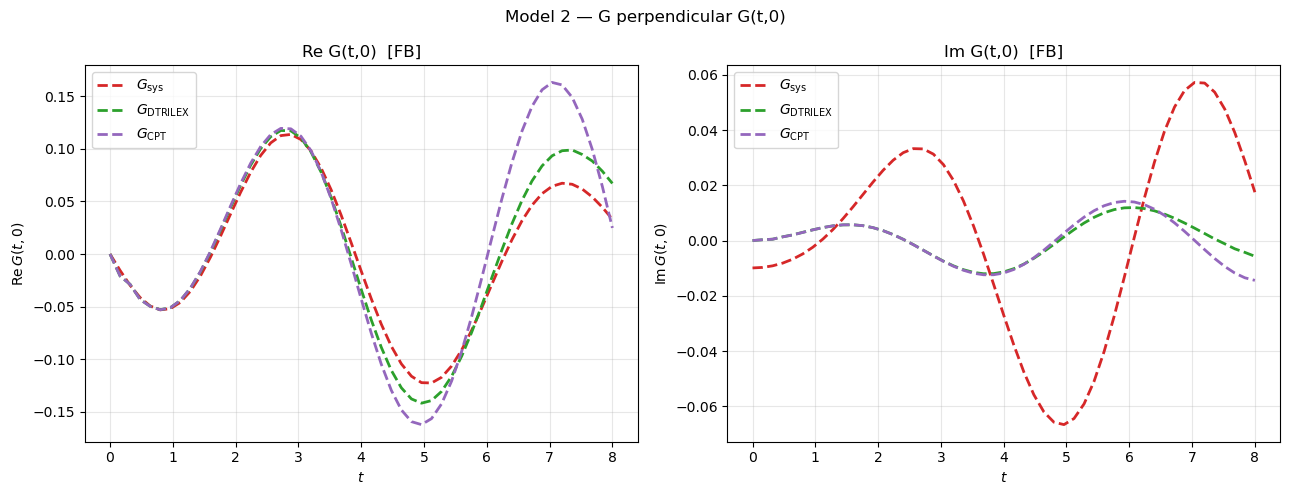

In [83]:
if model != 2:
    print("Skipping Model 2 line plot (model != 2)")
else:
    site_comp = "perpendicular"   # "parallel" or "perpendicular"
    kcomp     = "FB"

    propagators = {
        r"$G_\mathrm{sys}$":     f"sys/G_sys/{site_comp}",
        r"$G_\mathrm{DTRILEX}$": f"sys/G_dtrilex/{site_comp}",
        r"$G_\mathrm{CPT}$":     f"sys/G_cpt/{site_comp}",
    }
    colors = ["tab:red", "tab:green", "tab:purple"]

    fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Model 2 — G {site_comp} G(t,0)")

    with h5py.File(h5_path, "r") as f:
        t = f["t_mesh"][:]
        for (label, path), color in zip(propagators.items(), colors):
            G = load_Gt0(f, path, kcomp)
            ax_re.plot(t, G.real, color=color, lw=2, linestyle='--', label=label)
            ax_im.plot(t, G.imag, color=color, lw=2, linestyle='--', label=label)

    for ax, ylabel, title in [
        (ax_re, r"$\mathrm{Re}\,G(t,0)$", f"Re G(t,0)  [{kcomp}]"),
        (ax_im, r"$\mathrm{Im}\,G(t,0)$", f"Im G(t,0)  [{kcomp}]"),
    ]:
        ax.set_xlabel(r"$t$"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.legend(fontsize=10); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(plots_dir / f"M2_green_comparison_{site_comp}.png", dpi=150)
    plt.show()


In [78]:
if model != 2:
    print("Skipping Model 2 2D plots (model != 2)")
else:
    site_comp = "parallel"   # "parallel" or "perpendicular"

    with h5py.File(h5_path, 'r') as f:
        t_mesh = f['t_mesh'][:]
        t1, t2 = np.meshgrid(t_mesh, t_mesh, indexing='ij')

        # 1) Green's functions (FB branch)
        fig1, axes1 = plt.subplots(2, 3, figsize=(15, 8))
        fig1.suptitle(f"Green's Functions [{site_comp}] (FB branch)", fontsize=14)
        G_cpt_fb     = f[f'sys/G_cpt/{site_comp}/FB'][:, :, 0, 0]
        G_dtrilex_fb = f[f'sys/G_dtrilex/{site_comp}/FB'][:, :, 0, 0]
        G_sys_fb     = f[f'sys/G_sys/{site_comp}/FB'][:, :, 0, 0]
        vmin_re, vmax_re = np.real(G_sys_fb).min(), np.real(G_sys_fb).max()
        vmin_im, vmax_im = np.imag(G_sys_fb).min(), np.imag(G_sys_fb).max()
        plot_2d(t1, t2, G_cpt_fb,     'G_cpt',     axes1[0, 0], vmin=vmin_re, vmax=vmax_re)
        plot_2d(t1, t2, G_cpt_fb,     'G_cpt',     axes1[1, 0], vmin=vmin_im, vmax=vmax_im, is_imag=True)
        plot_2d(t1, t2, G_dtrilex_fb, 'G_dtrilex', axes1[0, 1], vmin=vmin_re, vmax=vmax_re)
        plot_2d(t1, t2, G_dtrilex_fb, 'G_dtrilex', axes1[1, 1], vmin=vmin_im, vmax=vmax_im, is_imag=True)
        plot_2d(t1, t2, G_sys_fb,     'G_sys',     axes1[0, 2], vmin=vmin_re, vmax=vmax_re)
        plot_2d(t1, t2, G_sys_fb,     'G_sys',     axes1[1, 2], vmin=vmin_im, vmax=vmax_im, is_imag=True)
        plt.tight_layout(); fig1.savefig(plots_dir / f'M2_G_comparison_{site_comp}.png', dpi=150); plt.close(fig1)
        print(f'Saved M2_G_comparison_{site_comp}.png')

        # 2) Dual self-energies
        fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
        fig2.suptitle(f'Dual Self-Energies [{site_comp}] (FB branch)', fontsize=14)
        sigma_fb    = f[f'dual/sigma_dual/{site_comp}/FB'][:, :, 0, 0]
        pi_ch_fb    = f[f'dual/pi_dual/{site_comp}/ch/FB'][:, :, 0, 0]
        pi_sp_fb    = f[f'dual/pi_dual/{site_comp}/sp/FB'][:, :, 0, 0]
        plot_2d(t1, t2, sigma_fb, 'sigma_dual',      axes2[0, 0]); plot_2d(t1, t2, sigma_fb, 'sigma_dual',      axes2[1, 0], is_imag=True)
        plot_2d(t1, t2, pi_ch_fb, 'pi_dual (charge)', axes2[0, 1]); plot_2d(t1, t2, pi_ch_fb, 'pi_dual (charge)', axes2[1, 1], is_imag=True)
        plot_2d(t1, t2, pi_sp_fb, 'pi_dual (spin)',   axes2[0, 2]); plot_2d(t1, t2, pi_sp_fb, 'pi_dual (spin)',   axes2[1, 2], is_imag=True)
        plt.tight_layout(); fig2.savefig(plots_dir / f'M2_dual_self_energies_{site_comp}.png', dpi=150); plt.close(fig2)
        print(f'Saved M2_dual_self_energies_{site_comp}.png')

        # 3) Dual propagators
        fig3, axes3 = plt.subplots(2, 3, figsize=(15, 8))
        fig3.suptitle(f'Dual Propagators [{site_comp}] (FB branch)', fontsize=14)
        w_ch_fb = f[f'dual/w_dual/{site_comp}/ch/FB'][:, :, 0, 0]
        w_sp_fb = f[f'dual/w_dual/{site_comp}/sp/FB'][:, :, 0, 0]
        plot_2d(t1, t2, sigma_fb, 'sigma_dual',      axes3[0, 0]); plot_2d(t1, t2, sigma_fb, 'sigma_dual',      axes3[1, 0], is_imag=True)
        plot_2d(t1, t2, w_ch_fb,  'w_dual (charge)', axes3[0, 1]); plot_2d(t1, t2, w_ch_fb,  'w_dual (charge)', axes3[1, 1], is_imag=True)
        plot_2d(t1, t2, w_sp_fb,  'w_dual (spin)',   axes3[0, 2]); plot_2d(t1, t2, w_sp_fb,  'w_dual (spin)',   axes3[1, 2], is_imag=True)
        plt.tight_layout(); fig3.savefig(plots_dir / f'M2_dual_propagators_{site_comp}.png', dpi=150); plt.close(fig3)
        print(f'Saved M2_dual_propagators_{site_comp}.png')

        # 4) Lambda — plot full (t1,t2) slice at t3=0
        fig4, axes4 = plt.subplots(1, 2, figsize=(11, 5))
        fig4.suptitle(r'$\Lambda(t_1, t_2, t_3{=}0)$, FBF  (sp channel)', fontsize=14)
        Lambda_FBF = f['ref/Lambda/sp/FBF'][:, :, 0, 0, 0, 0]   # shape (n_t, n_t)
        plot_2d(t1, t2, Lambda_FBF, r'$\Lambda$ (Re)', axes4[0])
        plot_2d(t1, t2, Lambda_FBF, r'$\Lambda$ (Im)', axes4[1], is_imag=True)
        plt.tight_layout(); fig4.savefig(plots_dir / 'M2_Lambda.png', dpi=150); plt.close(fig4)
        print('Saved M2_Lambda.png')


    print(f'All Model 2 plots saved to: {plots_dir}')


Saved M2_G_comparison_parallel.png
Saved M2_dual_self_energies_parallel.png
Saved M2_dual_propagators_parallel.png
Saved M2_Lambda.png
All Model 2 plots saved to: data/Mickey2/plots


# Parameter sweeps (NOT USED in normal runs)

## Model 1

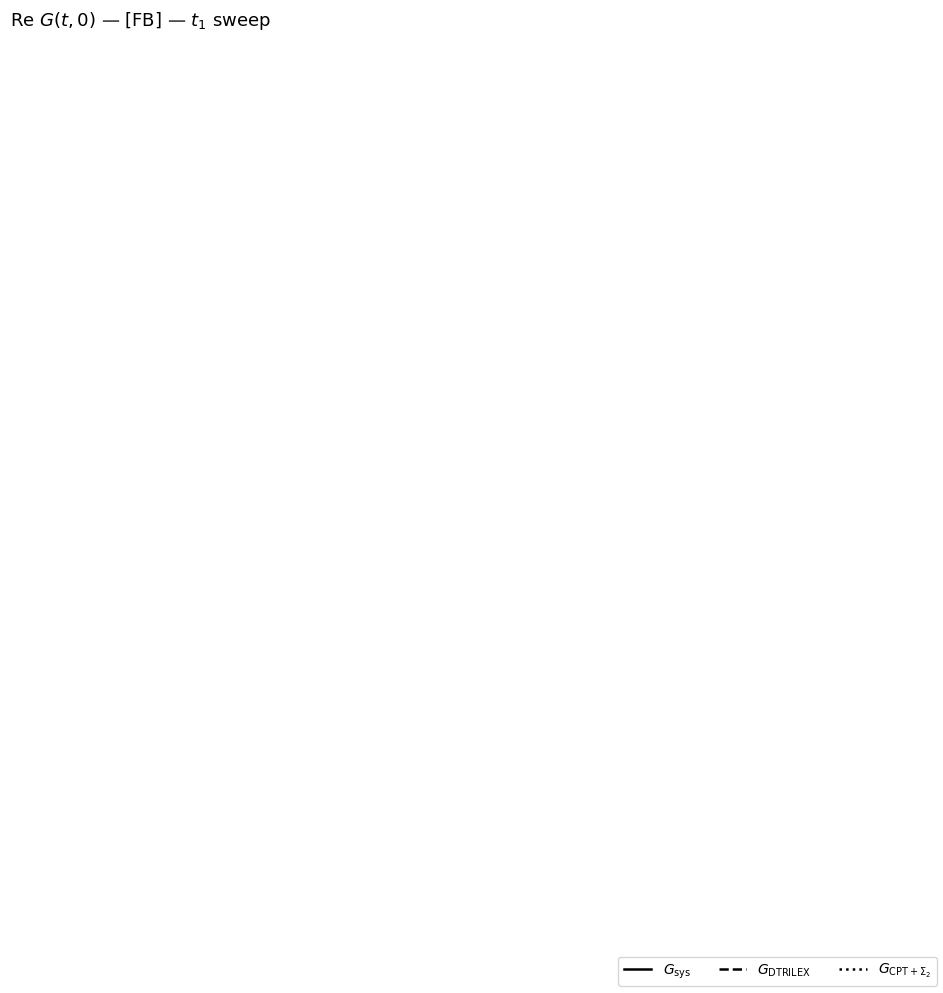

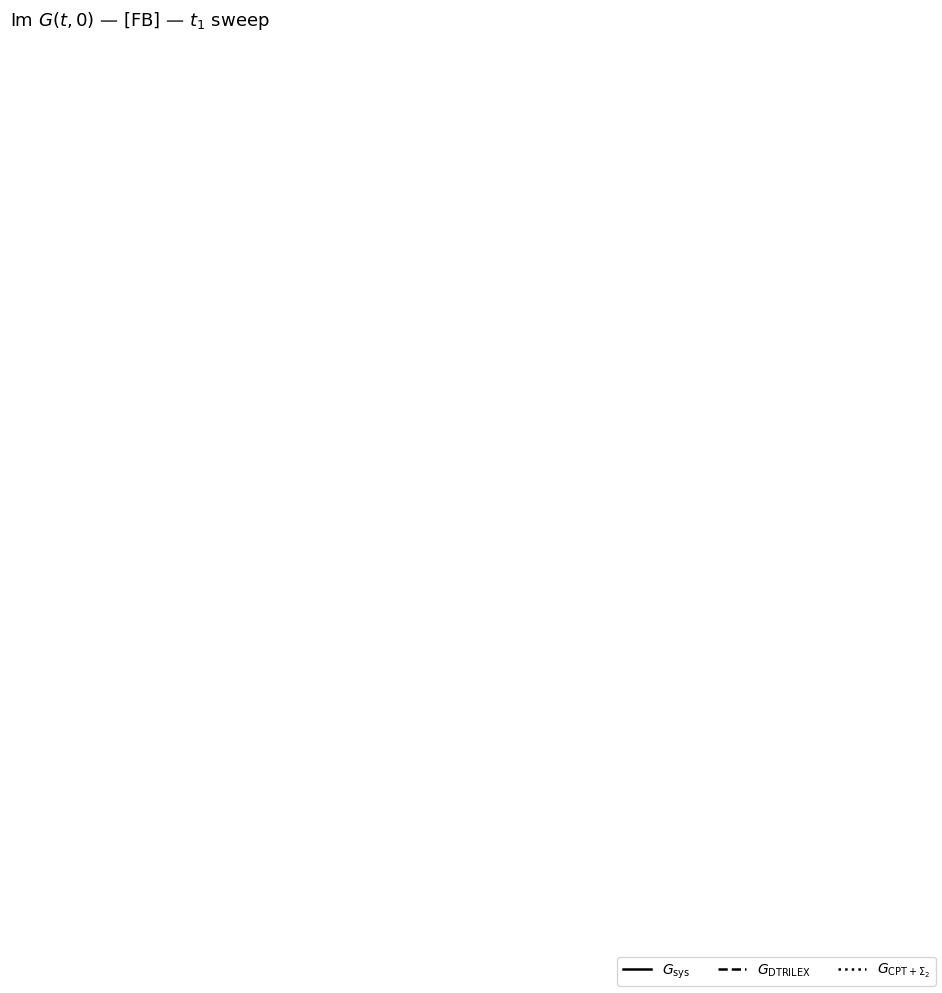

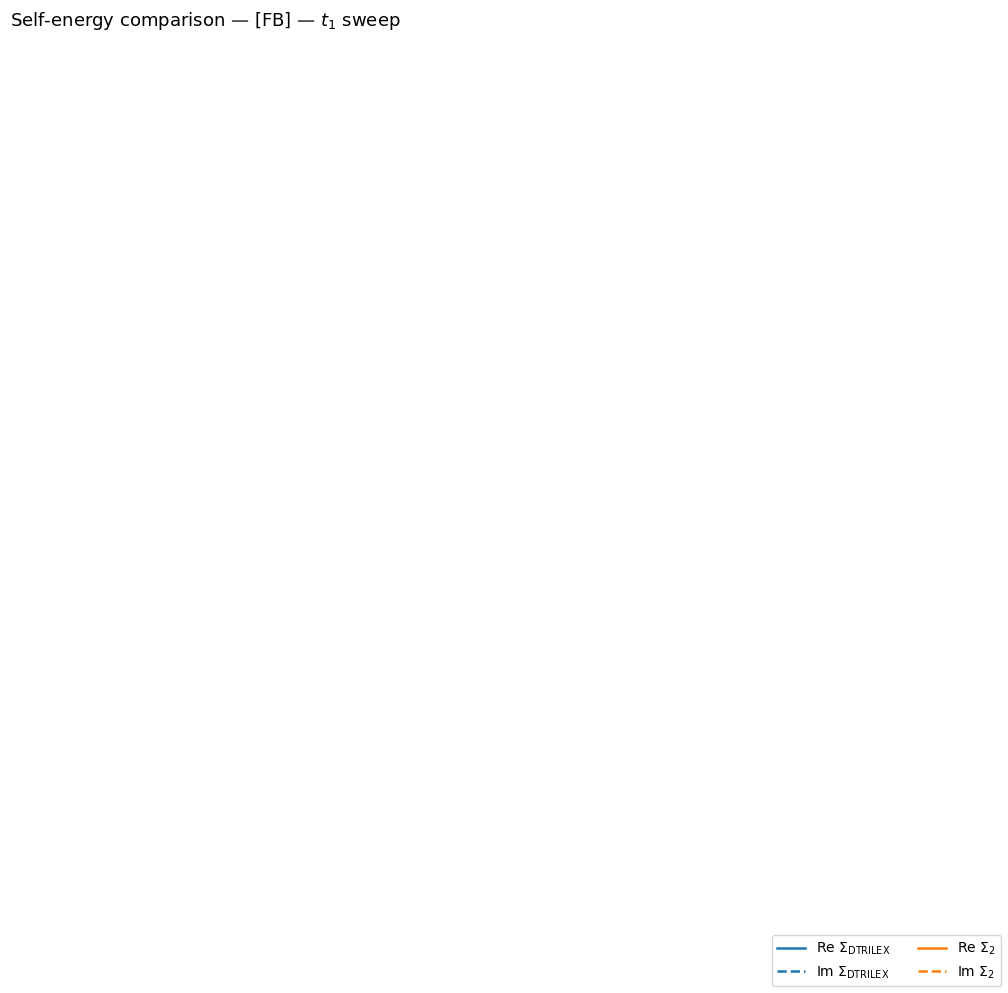

Saved: G_t1_sweep_Re.png, G_t1_sweep_Im.png, Sigma_t1_sweep.png


In [79]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from pathlib import Path
import re

component = "FB"
data_dir = data_dir
plots_dir = plots_dir

files = sorted(data_dir.glob("dtrimp_results_t1_*.h5"))
t1_values = []
for f in files:
    m = re.search(r"t1_([0-9.]+)\.h5", f.name)
    if m:
        t1_values.append(float(m.group(1)))
t1_values = np.array(t1_values)

def load_Gt0(f, group_path, comp):
    data = f[f"{group_path}/{comp}"][:]
    if data.ndim == 4:
        return data[0, :, 0, 0]
    return data[0, :]

# Pre-load all data
data_cache = {}
for t1, fpath in zip(t1_values, files):
    with h5py.File(fpath, "r") as f:
        t_mesh = f["t_mesh"][:]
        data_cache[t1] = {
            "t":          t_mesh,
            "G_sys":      load_Gt0(f, "sys/G_sys",      component),
            "G_dtrilex":  load_Gt0(f, "sys/G_dtrilex",  component),
            "G_cpt2":     load_Gt0(f, "sys/G_CPT_sigma2", component),
            "sigma_dtrilex": load_Gt0(f, "dual/sigma_dual", component),
            "sigma_2":    load_Gt0(f, "dual/sigma_2",    component),
        }

ncols = 4
nrows = 3   # ceil(11/4) = 3

def make_grid_fig(title):
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10), sharex=True)
    fig.suptitle(title, fontsize=13)
    # hide the unused last panel
    for idx in range(len(t1_values), nrows * ncols):
        axes.flat[idx].set_visible(False)
    return fig, axes

# ── Shared legend elements ──────────────────────────────────────────────
gf_legend = [
    Line2D([0], [0], color="k",  lw=1.8, ls="-",   label=r"$G_\mathrm{sys}$"),
    Line2D([0], [0], color="k",  lw=1.8, ls="--",  label=r"$G_\mathrm{DTRILEX}$"),
    Line2D([0], [0], color="k",  lw=1.8, ls=":",   label=r"$G_\mathrm{CPT+\Sigma_2}$"),
]
sig_legend = [
    Line2D([0], [0], color="k",  lw=1.8, ls="-",   label=r"$\Sigma_\mathrm{DTRILEX}$"),
    Line2D([0], [0], color="k",  lw=1.8, ls="--",  label=r"$\Sigma_2$"),
]

# ── Figure 1: Re G ──────────────────────────────────────────────────────
fig1, axes1 = make_grid_fig(f"Re $G(t,0)$ — [{component}] — $t_1$ sweep")
for idx, t1 in enumerate(t1_values):
    ax = axes1.flat[idx]
    d  = data_cache[t1]
    ax.plot(d["t"], d["G_sys"].real,     lw=1.8, ls="-")
    ax.plot(d["t"], d["G_dtrilex"].real, lw=1.8, ls="--")
    ax.plot(d["t"], d["G_cpt2"].real,    lw=1.8, ls=":")
    ax.set_title(f"$t_1={t1:.2f}$", fontsize=10)
    ax.set_xlim((0,8))
    ax.grid(alpha=0.3)
    if idx % ncols == 0:
        ax.set_ylabel(r"Re $G$")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel(r"$t$")
fig1.legend(handles=gf_legend, loc="lower right", fontsize=10, ncol=3)
fig1.tight_layout()
fig1.savefig(plots_dir / "G_t1_sweep_Re.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: Im G ──────────────────────────────────────────────────────
fig2, axes2 = make_grid_fig(f"Im $G(t,0)$ — [{component}] — $t_1$ sweep")
for idx, t1 in enumerate(t1_values):
    ax = axes2.flat[idx]
    d  = data_cache[t1]
    ax.plot(d["t"], d["G_sys"].imag,     lw=1.8, ls="-")
    ax.plot(d["t"], d["G_dtrilex"].imag, lw=1.8, ls="--")
    ax.plot(d["t"], d["G_cpt2"].imag,    lw=1.8, ls=":")
    ax.set_title(f"$t_1={t1:.2f}$", fontsize=10)
    ax.set_xlim((0,8))
    ax.grid(alpha=0.3)
    if idx % ncols == 0:
        ax.set_ylabel(r"Im $G$")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel(r"$t$")
fig2.legend(handles=gf_legend, loc="lower right", fontsize=10, ncol=3)
fig2.tight_layout()
fig2.savefig(plots_dir / "G_t1_sweep_Im.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 3: Self-energy comparison (Re + Im on same panel via twin ax) ─
fig3, axes3 = make_grid_fig(f"Self-energy comparison — [{component}] — $t_1$ sweep")
for idx, t1 in enumerate(t1_values):
    ax = axes3.flat[idx]
    d  = data_cache[t1]
    # Re: solid lines, Im: dashed — both on same axis, colour separates Re/Im
    c1, c2 = "tab:blue", "tab:orange"
    ax.plot(d["t"], d["sigma_dtrilex"].real, color=c1, lw=1.8, ls="-",  label=r"Re $\Sigma_\mathrm{D}$")
    ax.plot(d["t"], d["sigma_dtrilex"].imag, color=c1, lw=1.8, ls="--", label=r"Im $\Sigma_\mathrm{D}$")
    ax.plot(d["t"], d["sigma_2"].real,        color=c2, lw=1.8, ls="-",  label=r"Re $\Sigma_2$")
    ax.plot(d["t"], d["sigma_2"].imag,        color=c2, lw=1.8, ls="--", label=r"Im $\Sigma_2$")
    ax.set_xlim((0,8))
    ax.set_title(f"$t_1={t1:.2f}$", fontsize=10)
    ax.grid(alpha=0.3)
    if idx % ncols == 0:
        ax.set_ylabel(r"$\Sigma$")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel(r"$t$")

from matplotlib.lines import Line2D as L2D
sig_legend2 = [
    L2D([0],[0], color="tab:blue",   lw=1.8, ls="-",  label=r"Re $\Sigma_\mathrm{DTRILEX}$"),
    L2D([0],[0], color="tab:blue",   lw=1.8, ls="--", label=r"Im $\Sigma_\mathrm{DTRILEX}$"),
    L2D([0],[0], color="tab:orange", lw=1.8, ls="-",  label=r"Re $\Sigma_2$"),
    L2D([0],[0], color="tab:orange", lw=1.8, ls="--", label=r"Im $\Sigma_2$"),
]
fig3.legend(handles=sig_legend2, loc="lower right", fontsize=10, ncol=2)
fig3.tight_layout()
fig3.savefig(plots_dir / "Sigma_t1_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: G_t1_sweep_Re.png, G_t1_sweep_Im.png, Sigma_t1_sweep.png")

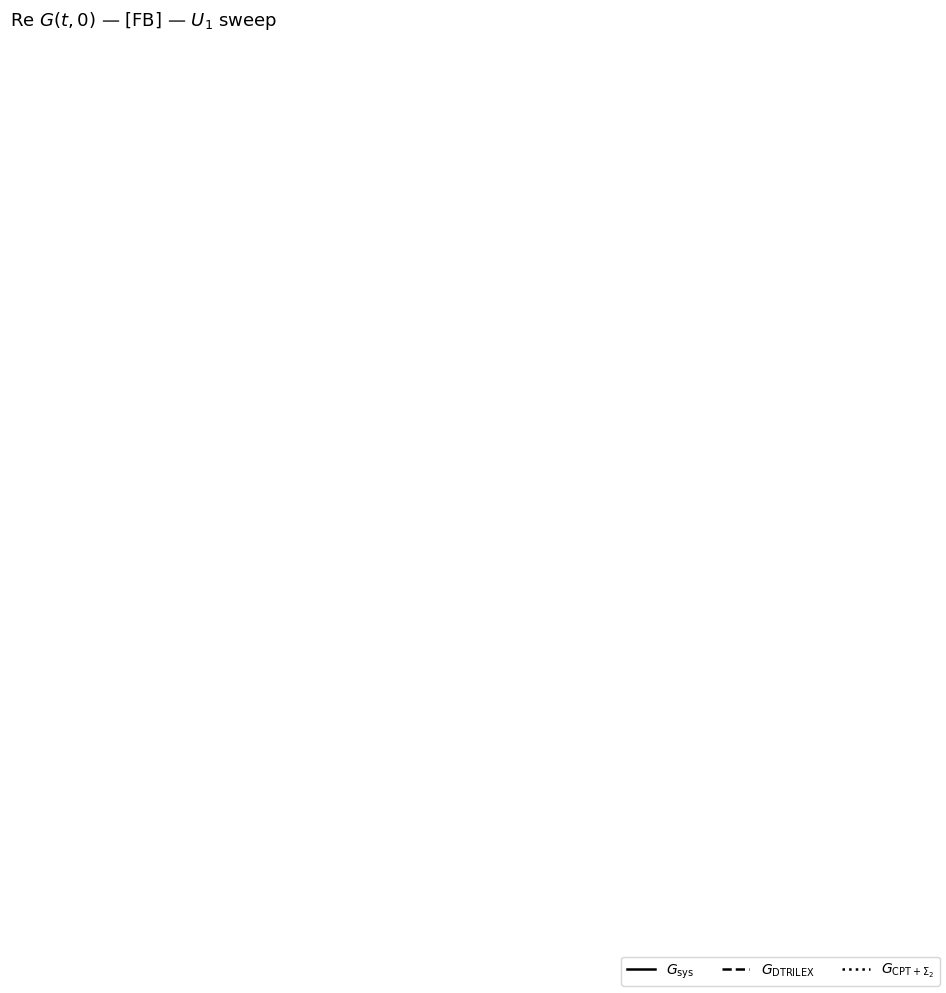

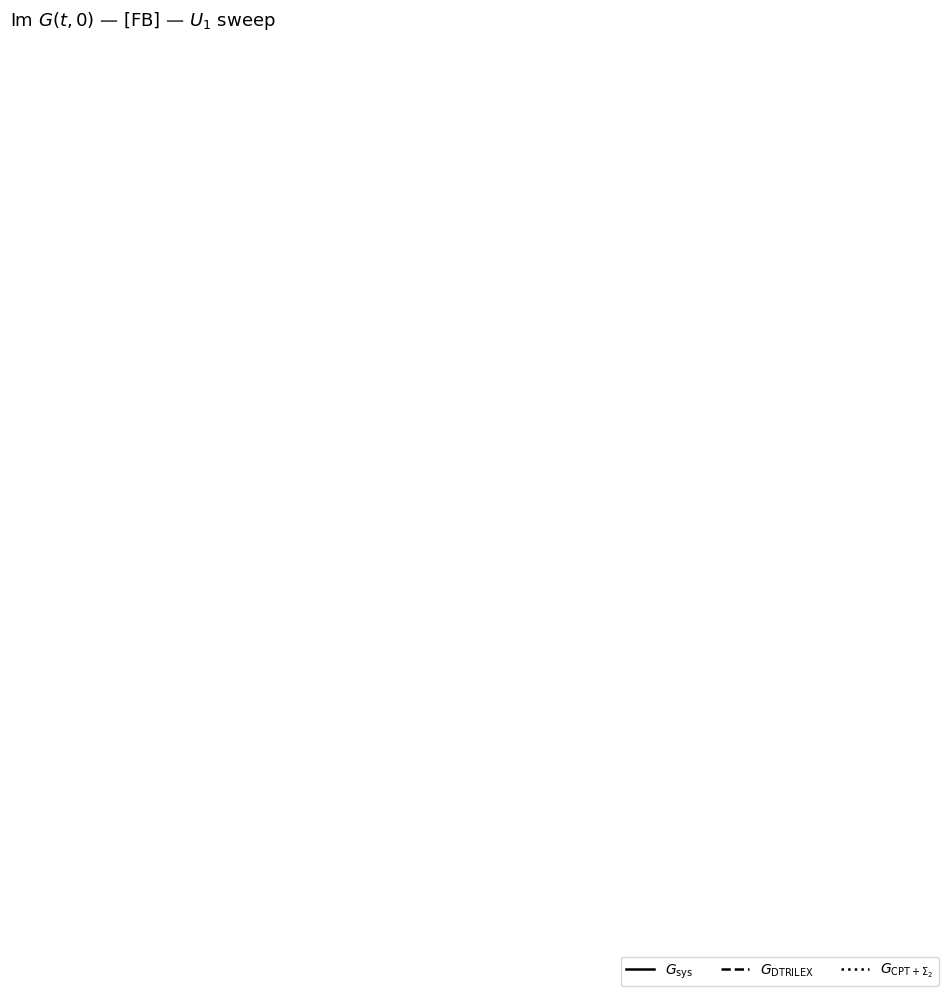

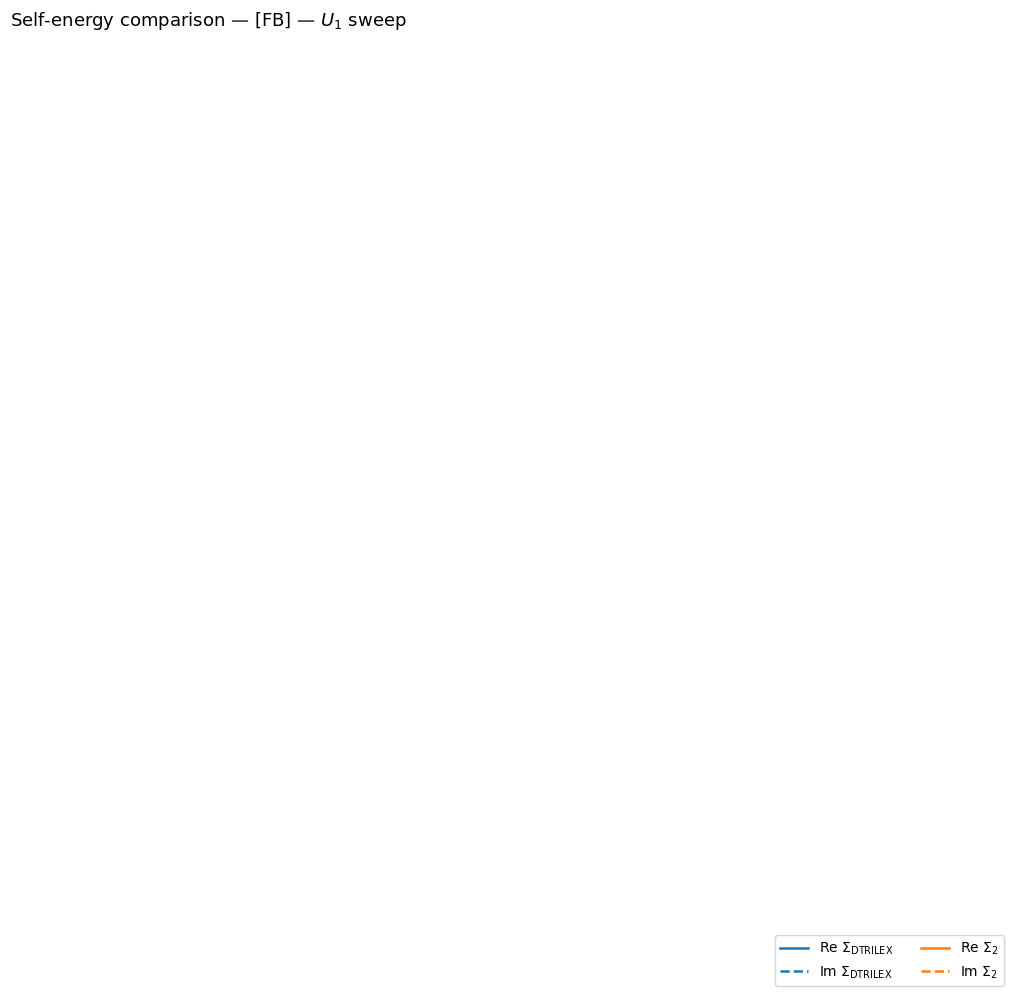

Saved: G_U1_sweep_Re.png, G_U1_sweep_Im.png, Sigma_U1_sweep.png


In [80]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import re

component = "FB"
data_dir = data_dir
plots_dir = plots_dir

files = sorted(data_dir.glob("dtrimp_results_U1_*.h5"))
U1_values = []
for f in files:
    m = re.search(r"U1_([0-9.]+)\.h5", f.name)
    if m:
        U1_values.append(float(m.group(1)))
U1_values = np.array(U1_values)

def load_Gt0(f, group_path, comp):
    data = f[f"{group_path}/{comp}"][:]
    if data.ndim == 4:
        return data[0, :, 0, 0]
    return data[0, :]

# Pre-load all data
data_cache = {}
for U1, fpath in zip(U1_values, files):
    with h5py.File(fpath, "r") as f:
        t_mesh = f["t_mesh"][:]
        data_cache[U1] = {
            "t":             t_mesh,
            "G_sys":         load_Gt0(f, "sys/G_sys",        component),
            "G_dtrilex":     load_Gt0(f, "sys/G_dtrilex",    component),
            "G_cpt2":        load_Gt0(f, "sys/G_CPT_sigma2", component),
            "sigma_dtrilex": load_Gt0(f, "dual/sigma_dual",  component),
            "sigma_2":       load_Gt0(f, "dual/sigma_2",     component),
        }

ncols = 4
nrows = 3  # ceil(11/4) = 3

def make_grid_fig(title):
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10), sharex=True)
    fig.suptitle(title, fontsize=13)
    for idx in range(len(U1_values), nrows * ncols):
        axes.flat[idx].set_visible(False)
    return fig, axes

gf_legend = [
    Line2D([0], [0], color="k", lw=1.8, ls="-",  label=r"$G_\mathrm{sys}$"),
    Line2D([0], [0], color="k", lw=1.8, ls="--", label=r"$G_\mathrm{DTRILEX}$"),
    Line2D([0], [0], color="k", lw=1.8, ls=":",  label=r"$G_\mathrm{CPT+\Sigma_2}$"),
]

# ── Figure 1: Re G ──────────────────────────────────────────────────────
fig1, axes1 = make_grid_fig(f"Re $G(t,0)$ — [{component}] — $U_1$ sweep")
for idx, U1 in enumerate(U1_values):
    ax = axes1.flat[idx]
    d  = data_cache[U1]
    ax.plot(d["t"], d["G_sys"].real,     lw=1.8, ls="-")
    ax.plot(d["t"], d["G_dtrilex"].real, lw=1.8, ls="--")
    ax.plot(d["t"], d["G_cpt2"].real,    lw=1.8, ls=":")
    ax.set_title(f"$U_1={U1:.2f}$", fontsize=10)
    ax.grid(alpha=0.3)
    if idx % ncols == 0:
        ax.set_ylabel(r"Re $G$")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel(r"$t$")
fig1.legend(handles=gf_legend, loc="lower right", fontsize=10, ncol=3)
fig1.tight_layout()
fig1.savefig(plots_dir / "G_U1_sweep_Re.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: Im G ──────────────────────────────────────────────────────
fig2, axes2 = make_grid_fig(f"Im $G(t,0)$ — [{component}] — $U_1$ sweep")
for idx, U1 in enumerate(U1_values):
    ax = axes2.flat[idx]
    d  = data_cache[U1]
    ax.plot(d["t"], d["G_sys"].imag,     lw=1.8, ls="-")
    ax.plot(d["t"], d["G_dtrilex"].imag, lw=1.8, ls="--")
    ax.plot(d["t"], d["G_cpt2"].imag,    lw=1.8, ls=":")
    ax.set_title(f"$U_1={U1:.2f}$", fontsize=10)
    ax.grid(alpha=0.3)
    if idx % ncols == 0:
        ax.set_ylabel(r"Im $G$")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel(r"$t$")
fig2.legend(handles=gf_legend, loc="lower right", fontsize=10, ncol=3)
fig2.tight_layout()
fig2.savefig(plots_dir / "G_U1_sweep_Im.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 3: Self-energy comparison ────────────────────────────────────
fig3, axes3 = make_grid_fig(f"Self-energy comparison — [{component}] — $U_1$ sweep")
c1, c2 = "tab:blue", "tab:orange"
for idx, U1 in enumerate(U1_values):
    ax = axes3.flat[idx]
    d  = data_cache[U1]
    ax.plot(d["t"], d["sigma_dtrilex"].real, color=c1, lw=1.8, ls="-")
    ax.plot(d["t"], d["sigma_dtrilex"].imag, color=c1, lw=1.8, ls="--")
    ax.plot(d["t"], d["sigma_2"].real,        color=c2, lw=1.8, ls="-")
    ax.plot(d["t"], d["sigma_2"].imag,        color=c2, lw=1.8, ls="--")
    ax.set_title(f"$U_1={U1:.2f}$", fontsize=10)
    ax.grid(alpha=0.3)
    if idx % ncols == 0:
        ax.set_ylabel(r"$\Sigma$")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel(r"$t$")

sig_legend = [
    Line2D([0],[0], color=c1, lw=1.8, ls="-",  label=r"Re $\Sigma_\mathrm{DTRILEX}$"),
    Line2D([0],[0], color=c1, lw=1.8, ls="--", label=r"Im $\Sigma_\mathrm{DTRILEX}$"),
    Line2D([0],[0], color=c2, lw=1.8, ls="-",  label=r"Re $\Sigma_2$"),
    Line2D([0],[0], color=c2, lw=1.8, ls="--", label=r"Im $\Sigma_2$"),
]
fig3.legend(handles=sig_legend, loc="lower right", fontsize=10, ncol=2)
fig3.tight_layout()
fig3.savefig(plots_dir / "Sigma_U1_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: G_U1_sweep_Re.png, G_U1_sweep_Im.png, Sigma_U1_sweep.png")

## Model 2

In [81]:
## ── dtrimp_2 PARALLEL ───────────────────────────────────────────────────
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import re

comp = "FB"
data_dir   = data_dir
plots_dir = plots_dir

files = sorted(data_dir.glob("dtrimp_2_results_t_perp_*.h5"))
t_perp_values = []
for f in files:
    m = re.search(r"t_perp_([0-9.]+)\.h5", f.name)
    if m:
        t_perp_values.append(float(m.group(1)))
t_perp_values = np.array(t_perp_values)

def load_Gt0(f, group_path, kcomp):
    data = f[f"{group_path}/{kcomp}"][:]
    if data.ndim == 4:
        return data[0, :, 0, 0]
    return data[0, :]

data_cache_par = {}
for t_perp, fpath in zip(t_perp_values, files):
    with h5py.File(fpath, "r") as f:
        data_cache_par[t_perp] = {
            "t":         f["t_mesh"][:],
            "G_sys":     load_Gt0(f, "sys/G_sys/parallel",      comp),
            "G_dtrilex": load_Gt0(f, "sys/G_dtrilex/parallel",  comp),
            "G_cpt":     load_Gt0(f, "sys/G_cpt/parallel",      comp),
            "sigma":     load_Gt0(f, "dual/sigma_dual/parallel", comp),
        }

n = len(t_perp_values)
ncols = 3
nrows = (n + ncols - 1) // ncols

def make_grid(title):
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows), sharex=True)
    fig.suptitle(title, fontsize=13)
    for idx in range(n, nrows * ncols):
        axes.flat[idx].set_visible(False)
    return fig, axes

gf_legend = [
    Line2D([0],[0], color="k", lw=1.8, ls="-",  label=r"$G_\mathrm{sys}$"),
    Line2D([0],[0], color="k", lw=1.8, ls="--", label=r"$G_\mathrm{DTRILEX}$"),
    Line2D([0],[0], color="k", lw=1.8, ls=":",  label=r"$G_\mathrm{CPT}$"),
]

# Re G
fig1, axes1 = make_grid(f"PARALLEL — Re $G(t,0)$ [{comp}] — $t_\\perp$ sweep")
for idx, t_perp in enumerate(t_perp_values):
    ax = axes1.flat[idx]; d = data_cache_par[t_perp]
    ax.plot(d["t"], d["G_sys"].real,     lw=1.8, ls="-")
    ax.plot(d["t"], d["G_dtrilex"].real, lw=1.8, ls="--")
    ax.plot(d["t"], d["G_cpt"].real,     lw=1.8, ls=":")
    ax.set_title(f"$t_\\perp={t_perp:.2f}$", fontsize=10)
    ax.grid(alpha=0.3)
    if idx % ncols == 0: ax.set_ylabel(r"Re $G^{\parallel}$")
    if idx >= (nrows-1)*ncols: ax.set_xlabel(r"$t$")
fig1.legend(handles=gf_legend, loc="lower right", fontsize=10, ncol=3)
fig1.tight_layout()
fig1.savefig(plots_dir / "G2_par_Re.png", dpi=150, bbox_inches="tight")
plt.show()

# Im G
fig2, axes2 = make_grid(f"PARALLEL — Im $G(t,0)$ [{comp}] — $t_\\perp$ sweep")
for idx, t_perp in enumerate(t_perp_values):
    ax = axes2.flat[idx]; d = data_cache_par[t_perp]
    ax.plot(d["t"], d["G_sys"].imag,     lw=1.8, ls="-")
    ax.plot(d["t"], d["G_dtrilex"].imag, lw=1.8, ls="--")
    ax.plot(d["t"], d["G_cpt"].imag,     lw=1.8, ls=":")
    ax.set_title(f"$t_\\perp={t_perp:.2f}$", fontsize=10)
    ax.grid(alpha=0.3)
    if idx % ncols == 0: ax.set_ylabel(r"Im $G^{\parallel}$")
    if idx >= (nrows-1)*ncols: ax.set_xlabel(r"$t$")
fig2.legend(handles=gf_legend, loc="lower right", fontsize=10, ncol=3)
fig2.tight_layout()
fig2.savefig(plots_dir / "G2_par_Im.png", dpi=150, bbox_inches="tight")
plt.show()

# Sigma
fig3, axes3 = make_grid(f"PARALLEL — $\\Sigma(t,0)$ [{comp}] — $t_\\perp$ sweep")
for idx, t_perp in enumerate(t_perp_values):
    ax = axes3.flat[idx]; d = data_cache_par[t_perp]
    ax.plot(d["t"], d["sigma"].real, color="tab:blue", lw=1.8, ls="-",  label=r"Re")
    ax.plot(d["t"], d["sigma"].imag, color="tab:blue", lw=1.8, ls="--", label=r"Im")
    ax.set_title(f"$t_\\perp={t_perp:.2f}$", fontsize=10)
    ax.grid(alpha=0.3)
    if idx % ncols == 0: ax.set_ylabel(r"$\Sigma^{\parallel}$")
    if idx >= (nrows-1)*ncols: ax.set_xlabel(r"$t$")
sig_legend = [
    Line2D([0],[0], color="tab:blue", lw=1.8, ls="-",  label=r"Re $\Sigma^{\parallel}$"),
    Line2D([0],[0], color="tab:blue", lw=1.8, ls="--", label=r"Im $\Sigma^{\parallel}$"),
]
fig3.legend(handles=sig_legend, loc="lower right", fontsize=10, ncol=2)
fig3.tight_layout()
fig3.savefig(plots_dir / "Sigma2_par.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: G2_par_Re.png, G2_par_Im.png, Sigma2_par.png")

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1400x0 with 0 Axes>

In [ ]:
## ── dtrimp_2 PERPENDICULAR ──────────────────────────────────────────────
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import re

comp = "FB"
data_dir   = data_dir
plots_dir = plots_dir

files = sorted(data_dir.glob("dtrimp_2_results_t_perp_*.h5"))
t_perp_values = []
for f in files:
    m = re.search(r"t_perp_([0-9.]+)\.h5", f.name)
    if m:
        t_perp_values.append(float(m.group(1)))
t_perp_values = np.array(t_perp_values)

def load_Gt0(f, group_path, kcomp):
    data = f[f"{group_path}/{kcomp}"][:]
    if data.ndim == 4:
        return data[0, :, 0, 0]
    return data[0, :]

data_cache_perp = {}
for t_perp, fpath in zip(t_perp_values, files):
    with h5py.File(fpath, "r") as f:
        data_cache_perp[t_perp] = {
            "t":         f["t_mesh"][:],
            "G_sys":     load_Gt0(f, "sys/G_sys/perpendicular",      comp),
            "G_dtrilex": load_Gt0(f, "sys/G_dtrilex/perpendicular",  comp),
            "G_cpt":     load_Gt0(f, "sys/G_cpt/perpendicular",      comp),
            "sigma":     load_Gt0(f, "dual/sigma_dual/perpendicular", comp),
        }

n = len(t_perp_values)
ncols = 3
nrows = (n + ncols - 1) // ncols

def make_grid(title):
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows), sharex=True)
    fig.suptitle(title, fontsize=13)
    for idx in range(n, nrows * ncols):
        axes.flat[idx].set_visible(False)
    return fig, axes

gf_legend = [
    Line2D([0],[0], color="k", lw=1.8, ls="-",  label=r"$G_\mathrm{sys}$"),
    Line2D([0],[0], color="k", lw=1.8, ls="--", label=r"$G_\mathrm{DTRILEX}$"),
    Line2D([0],[0], color="k", lw=1.8, ls=":",  label=r"$G_\mathrm{CPT}$"),
]

# Re G
fig1, axes1 = make_grid(f"PERPENDICULAR — Re $G(t,0)$ [{comp}] — $t_\\perp$ sweep")
for idx, t_perp in enumerate(t_perp_values):
    ax = axes1.flat[idx]; d = data_cache_perp[t_perp]
    ax.plot(d["t"], d["G_sys"].real,     lw=1.8, ls="-")
    ax.plot(d["t"], d["G_dtrilex"].real, lw=1.8, ls="--")
    ax.plot(d["t"], d["G_cpt"].real,     lw=1.8, ls=":")
    ax.set_title(f"$t_\\perp={t_perp:.2f}$", fontsize=10)
    ax.grid(alpha=0.3)
    if idx % ncols == 0: ax.set_ylabel(r"Re $G^{\perp}$")
    if idx >= (nrows-1)*ncols: ax.set_xlabel(r"$t$")
fig1.legend(handles=gf_legend, loc="lower right", fontsize=10, ncol=3)
fig1.tight_layout()
fig1.savefig(plots_dir / "G2_perp_Re.png", dpi=150, bbox_inches="tight")
plt.show()

# Im G
fig2, axes2 = make_grid(f"PERPENDICULAR — Im $G(t,0)$ [{comp}] — $t_\\perp$ sweep")
for idx, t_perp in enumerate(t_perp_values):
    ax = axes2.flat[idx]; d = data_cache_perp[t_perp]
    ax.plot(d["t"], d["G_sys"].imag,     lw=1.8, ls="-")
    ax.plot(d["t"], d["G_dtrilex"].imag, lw=1.8, ls="--")
    ax.plot(d["t"], d["G_cpt"].imag,     lw=1.8, ls=":")
    ax.set_title(f"$t_\\perp={t_perp:.2f}$", fontsize=10)
    ax.grid(alpha=0.3)
    if idx % ncols == 0: ax.set_ylabel(r"Im $G^{\perp}$")
    if idx >= (nrows-1)*ncols: ax.set_xlabel(r"$t$")
fig2.legend(handles=gf_legend, loc="lower right", fontsize=10, ncol=3)
fig2.tight_layout()
fig2.savefig(plots_dir / "G2_perp_Im.png", dpi=150, bbox_inches="tight")
plt.show()

# Sigma
fig3, axes3 = make_grid(f"PERPENDICULAR — $\\Sigma(t,0)$ [{comp}] — $t_\\perp$ sweep")
for idx, t_perp in enumerate(t_perp_values):
    ax = axes3.flat[idx]; d = data_cache_perp[t_perp]
    ax.plot(d["t"], d["sigma"].real, color="tab:orange", lw=1.8, ls="-")
    ax.plot(d["t"], d["sigma"].imag, color="tab:orange", lw=1.8, ls="--")
    ax.set_title(f"$t_\\perp={t_perp:.2f}$", fontsize=10)
    ax.grid(alpha=0.3)
    if idx % ncols == 0: ax.set_ylabel(r"$\Sigma^{\perp}$")
    if idx >= (nrows-1)*ncols: ax.set_xlabel(r"$t$")
sig_legend = [
    Line2D([0],[0], color="tab:orange", lw=1.8, ls="-",  label=r"Re $\Sigma^{\perp}$"),
    Line2D([0],[0], color="tab:orange", lw=1.8, ls="--", label=r"Im $\Sigma^{\perp}$"),
]
fig3.legend(handles=sig_legend, loc="lower right", fontsize=10, ncol=2)
fig3.tight_layout()
fig3.savefig(plots_dir / "Sigma2_perp.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: G2_perp_Re.png, G2_perp_Im.png, Sigma2_perp.png")

## D-bath sweep (Mickey-Mouse 1)


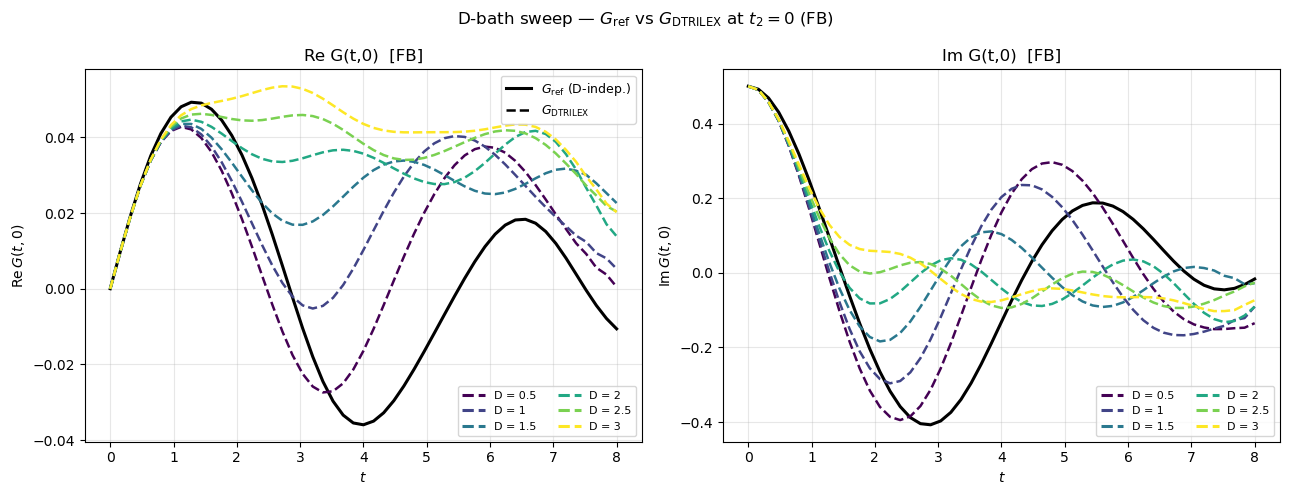

Plotted 6 D values: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]


In [ ]:
# ── D-bath sweep overlay (Mickey-Mouse 1) ────────────────────────────────
# Loads dtrimp_D*.h5 files produced by run_D_sweep.sh and overlays
# G_DTRILEX (at t2=0) for all bath half-bandwidths D. G_ref does not depend
# on D, so it is plotted once (from the first file).
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from pathlib import Path

sweep_dir = data_dir
component = "FB"

files = sorted(sweep_dir.glob("dtrimp_D*.h5"))
pairs = []
for f in files:
    m = re.search(r"dtrimp_D([0-9.]+)\.h5", f.name)
    if m:
        pairs.append((float(m.group(1)), f))
pairs.sort(key=lambda x: x[0])

if not pairs:
    print(f"No dtrimp_D*.h5 files found in {sweep_dir} — run programs/run_D_sweep.sh first.")
else:
    D_vals = [d for d, _ in pairs]
    cmap   = cm.viridis
    norm   = plt.Normalize(vmin=min(D_vals), vmax=max(D_vals) if max(D_vals) > min(D_vals) else min(D_vals) + 1)

    fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(r"D-bath sweep — $G_\mathrm{ref}$ vs $G_\mathrm{DTRILEX}$ at $t_2{=}0$ (FB)")

    # G_ref is D-independent — plot once from the first file
    with h5py.File(pairs[0][1], "r") as f:
        t     = f["t_mesh"][:]
        G_ref = load_Gt0(f, "ref/G_ref", component)
    ax_re.plot(t, G_ref.real, color="k", ls="-", lw=2.2, label=r"$G_\mathrm{ref}$")
    ax_im.plot(t, G_ref.imag, color="k", ls="-", lw=2.2, label=r"$G_\mathrm{ref}$")

    for D, fpath in pairs:
        color = cmap(norm(D))
        with h5py.File(fpath, "r") as f:
            G_dtri = load_Gt0(f, "sys/G_dtrilex", component)
        ax_re.plot(t, G_dtri.real, color=color, ls="--", lw=1.8)
        ax_im.plot(t, G_dtri.imag, color=color, ls="--", lw=1.8)

    style_legend = [
        Line2D([0], [0], color="k", ls="-",  lw=2.2, label=r"$G_\mathrm{ref}$ (D-indep.)"),
        Line2D([0], [0], color="k", ls="--", lw=1.8, label=r"$G_\mathrm{DTRILEX}$"),
    ]
    D_legend = [Line2D([0], [0], color=cmap(norm(D)), ls="--", lw=2.2, label=f"D = {D:g}") for D in D_vals]

    for ax, ylabel, title in [
        (ax_re, r"$\mathrm{Re}\,G(t,0)$", f"Re G(t,0)  [{component}]"),
        (ax_im, r"$\mathrm{Im}\,G(t,0)$", f"Im G(t,0)  [{component}]"),
    ]:
        ax.set_xlabel(r"$t$"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.grid(alpha=0.3)

    leg1 = ax_re.legend(handles=style_legend, fontsize=9, loc="upper right")
    ax_re.add_artist(leg1)
    ax_re.legend(handles=D_legend, fontsize=8, loc="lower right", ncol=2)
    ax_im.legend(handles=D_legend, fontsize=8, loc="lower right", ncol=2)

    plt.tight_layout()
    plt.savefig(plots_dir / "M1_D_sweep_Gref_Gdtrilex.png", dpi=200)
    plt.show()
    print(f"Plotted {len(pairs)} D values: {D_vals}")


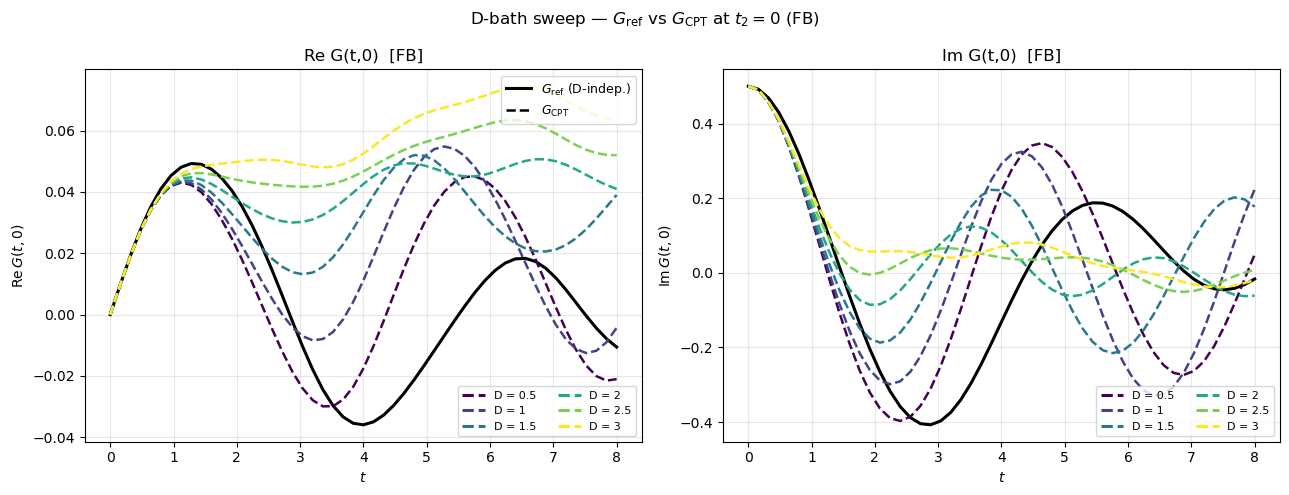

Plotted G_CPT for 6 D values: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]


In [ ]:
# ── D-bath sweep overlay — CPT (Mickey-Mouse 1) ──────────────────────────
# Overlays G_CPT (at t2=0) for all bath half-bandwidths D.
# G_ref is D-independent, plotted once from the first file.
import re
import h5py
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

sweep_dir = data_dir
component = "FB"

files = sorted(sweep_dir.glob("dtrimp_D*.h5"))
pairs = []
for f in files:
    m = re.search(r"dtrimp_D([0-9.]+)\.h5", f.name)
    if m:
        pairs.append((float(m.group(1)), f))
pairs.sort(key=lambda x: x[0])

if not pairs:
    print(f"No dtrimp_D*.h5 files found in {sweep_dir} — run programs/run_D_sweep.sh first.")
else:
    D_vals = [d for d, _ in pairs]
    cmap   = cm.viridis
    norm   = plt.Normalize(vmin=min(D_vals), vmax=max(D_vals) if max(D_vals) > min(D_vals) else min(D_vals) + 1)

    fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(r"D-bath sweep — $G_\mathrm{ref}$ vs $G_\mathrm{CPT}$ at $t_2{=}0$ (FB)")

    with h5py.File(pairs[0][1], "r") as f:
        t     = f["t_mesh"][:]
        G_ref = load_Gt0(f, "ref/G_ref", component)
    ax_re.plot(t, G_ref.real, color="k", ls="-", lw=2.2)
    ax_im.plot(t, G_ref.imag, color="k", ls="-", lw=2.2)

    for D, fpath in pairs:
        color = cmap(norm(D))
        with h5py.File(fpath, "r") as f:
            G_cpt = load_Gt0(f, "sys/G_cpt", component)
        ax_re.plot(t, G_cpt.real, color=color, ls="--", lw=1.8)
        ax_im.plot(t, G_cpt.imag, color=color, ls="--", lw=1.8)

    style_legend = [
        Line2D([0], [0], color="k", ls="-",  lw=2.2, label=r"$G_\mathrm{ref}$ (D-indep.)"),
        Line2D([0], [0], color="k", ls="--", lw=1.8, label=r"$G_\mathrm{CPT}$"),
    ]
    D_legend = [Line2D([0], [0], color=cmap(norm(D)), ls="--", lw=2.2, label=f"D = {D:g}") for D in D_vals]

    for ax, ylabel, title in [
        (ax_re, r"$\mathrm{Re}\,G(t,0)$", f"Re G(t,0)  [{component}]"),
        (ax_im, r"$\mathrm{Im}\,G(t,0)$", f"Im G(t,0)  [{component}]"),
    ]:
        ax.set_xlabel(r"$t$"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.grid(alpha=0.3)

    leg1 = ax_re.legend(handles=style_legend, fontsize=9, loc="upper right")
    ax_re.add_artist(leg1)
    ax_re.legend(handles=D_legend, fontsize=8, loc="lower right", ncol=2)
    ax_im.legend(handles=D_legend, fontsize=8, loc="lower right", ncol=2)

    plt.tight_layout()
    plt.savefig(plots_dir / "M1_D_sweep_Gref_Gcpt.png", dpi=200)
    plt.show()
    print(f"Plotted G_CPT for {len(pairs)} D values: {D_vals}")


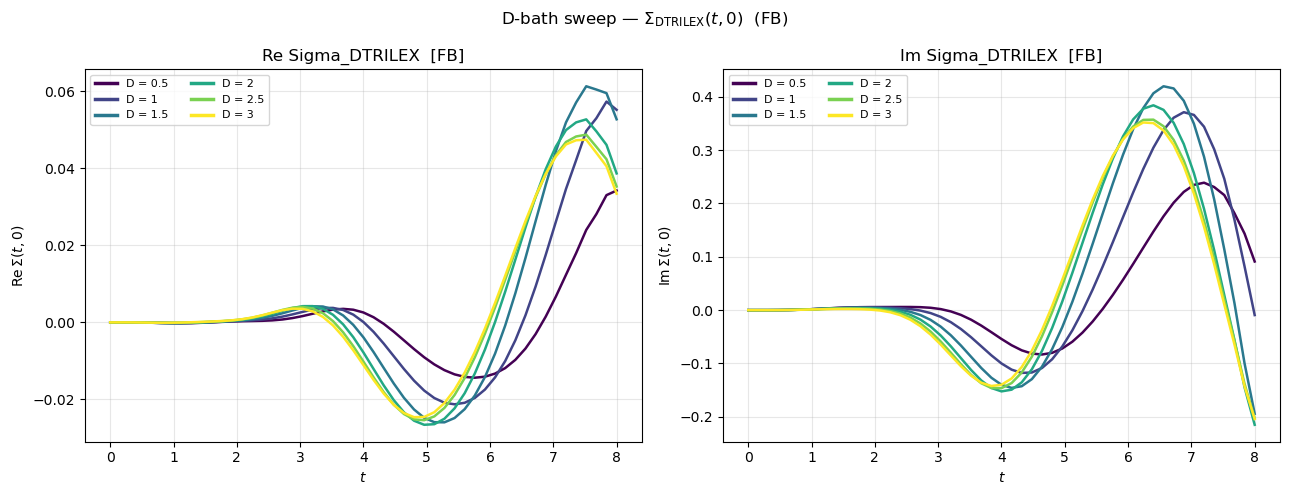

Plotted Sigma_DTRILEX for 6 D values: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]


In [ ]:
# ── D-bath sweep overlay — Self-energies (Mickey-Mouse 1) ────────────────
# Overlays Sigma_DTRILEX (= dual/sigma_dual) at t2=0 for all bath half-bandwidths D.
import re
import h5py
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

sweep_dir = data_dir
component = "FB"

files = sorted(sweep_dir.glob("dtrimp_D*.h5"))
pairs = []
for f in files:
    m = re.search(r"dtrimp_D([0-9.]+)\.h5", f.name)
    if m:
        pairs.append((float(m.group(1)), f))
pairs.sort(key=lambda x: x[0])

if not pairs:
    print(f"No dtrimp_D*.h5 files found in {sweep_dir} — run programs/run_D_sweep.sh first.")
else:
    D_vals = [d for d, _ in pairs]
    cmap   = cm.viridis
    norm   = plt.Normalize(vmin=min(D_vals), vmax=max(D_vals) if max(D_vals) > min(D_vals) else min(D_vals) + 1)

    fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(r"D-bath sweep — $\Sigma_\mathrm{DTRILEX}(t,0)$  (FB)")

    for D, fpath in pairs:
        color = cmap(norm(D))
        with h5py.File(fpath, "r") as f:
            t        = f["t_mesh"][:]
            sigma_dt = load_Gt0(f, "dual/sigma_dual", component)
        ax_re.plot(t, sigma_dt.real, color=color, lw=1.8)
        ax_im.plot(t, sigma_dt.imag, color=color, lw=1.8)

    D_legend = [Line2D([0], [0], color=cmap(norm(D)), lw=2.5, label=f"D = {D:g}") for D in D_vals]

    for ax, ylabel, title in [
        (ax_re, r"$\mathrm{Re}\,\Sigma(t,0)$", f"Re Sigma_DTRILEX  [{component}]"),
        (ax_im, r"$\mathrm{Im}\,\Sigma(t,0)$", f"Im Sigma_DTRILEX  [{component}]"),
    ]:
        ax.set_xlabel(r"$t$"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.grid(alpha=0.3)
        ax.legend(handles=D_legend, fontsize=8, loc="best", ncol=2)

    plt.tight_layout()
    plt.savefig(plots_dir / "M1_D_sweep_Sigma_DTRILEX.png", dpi=200)
    plt.show()
    print(f"Plotted Sigma_DTRILEX for {len(pairs)} D values: {D_vals}")


## Biased-junction current experiment

In [ ]:
import h5py, numpy as np, matplotlib.pyplot as plt
import os as _os

_here = _os.path.dirname(_os.path.abspath("plot_results.ipynb"))
for _candidate in [
    _os.path.join(_here, "data/current/current_results.h5"),
    _os.path.join(_here, "programs/data/current/current_results.h5"),
]:
    if _os.path.exists(_candidate):
        H5_PATH = _candidate
        break
else:
    raise FileNotFoundError("current_results.h5 not found; run current_run.py first")
print("Loading:", H5_PATH)

with h5py.File(H5_PATH, "r") as f:
    t_mesh  = f["t_mesh"][:]
    V_bias  = float(f["V_bias"][()])
    t_perp  = float(f["t_perp"][()])

    # Reference GF (n_t, n_t, 1, 1) -- same for both sites, squeeze to (n_t, n_t)
    G_ref_BF = f["ref/G_ref/BF"][:].squeeze()
    G_ref_FB = f["ref/G_ref/FB"][:].squeeze()

    # D-TRILEX physical GF (n_t, n_t, 2, 2)
    G_dtrilex_BF = f["sys/G_dtrilex/BF"][:]
    G_dtrilex_FB = f["sys/G_dtrilex/FB"][:]

    # CPT GF
    G_cpt_BF = f["sys/G_cpt/BF"][:]
    G_cpt_FB = f["sys/G_cpt/FB"][:]

    # System impurity GF (n_t, n_t, 2, 2)
    G_sys_BF = f["sys/G_sys/BF"][:]
    G_sys_FB = f["sys/G_sys/FB"][:]

    # Dual self-energy (n_t, n_t, 2, 2)
    Sigma_BF = f["dual/sigma_dual/BF"][:]
    Sigma_FB = f["dual/sigma_dual/FB"][:]

n_t = len(t_mesh)
sites = [(0, "site 0 (00)"), (1, "site 1 (11)")]
print(f"Loaded: n_t={n_t}, V_bias={V_bias}, t_perp={t_perp}")


Loading: /Users/gusein.bedirkhanov/Documents/PhD/FULL_DTRILEX_ON_KELDYSH/tddt/programs/data/current/current_results.h5
Loaded: n_t=50, V_bias=5.0, t_perp=0.5


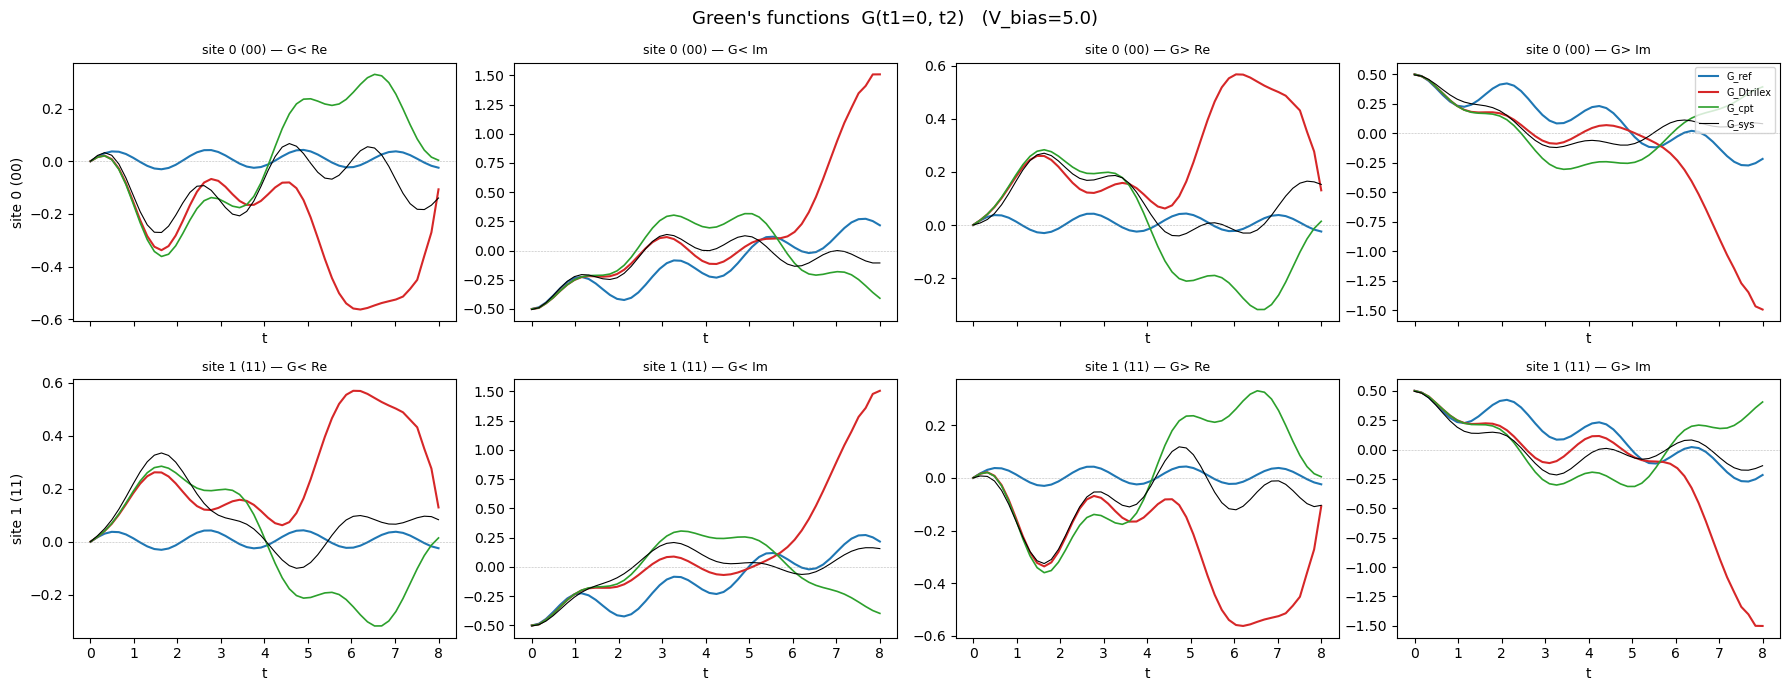

In [ ]:
# Plot 1: G_ref vs G_Dtrilex vs G_cpt vs G_sys
# rows = sites (00, 11),  cols = (G<(0,t) Re | G<(0,t) Im | G>(0,t) Re | G>(0,t) Im)
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
fig.suptitle(f"Green's functions  G(t1=0, t2)   (V_bias={V_bias})", fontsize=13)

col_labels = ["G< Re", "G< Im", "G> Re", "G> Im"]
colors  = ["tab:blue", "tab:red", "tab:green", "k"]
labels  = ["G_ref", "G_Dtrilex", "G_cpt", "G_sys"]
lwidths = [1.5, 1.5, 1.2, 0.8]

for row, (s, slabel) in enumerate(sites):
    g_ref_lt  = G_ref_BF[0, :]           # same ref for both sites
    g_ref_gt  = G_ref_FB[0, :]
    g_dtri_lt = G_dtrilex_BF[0, :, s, s]
    g_dtri_gt = G_dtrilex_FB[0, :, s, s]
    g_cpt_lt  = G_cpt_BF[0, :, s, s]
    g_cpt_gt  = G_cpt_FB[0, :, s, s]
    g_sys_lt  = G_sys_BF[0, :, s, s]
    g_sys_gt  = G_sys_FB[0, :, s, s]

    data = [
        (g_ref_lt.real,  g_dtri_lt.real, g_cpt_lt.real,  g_sys_lt.real),
        (g_ref_lt.imag,  g_dtri_lt.imag, g_cpt_lt.imag,  g_sys_lt.imag),
        (g_ref_gt.real,  g_dtri_gt.real, g_cpt_gt.real,  g_sys_gt.real),
        (g_ref_gt.imag,  g_dtri_gt.imag, g_cpt_gt.imag,  g_sys_gt.imag),
    ]

    for col, (vals, clabel) in enumerate(zip(data, col_labels)):
        ax = axes[row, col]
        for v, c, lbl, lw in zip(vals, colors, labels, lwidths):
            ax.plot(t_mesh, v, color=c, lw=lw, label=lbl)
        ax.axhline(0, color="gray", lw=0.4, ls=":")
        ax.set_title(f"{slabel} — {clabel}", fontsize=9)
        ax.set_xlabel("t")
        if col == 0:
            ax.set_ylabel(slabel)
        if row == 0 and col == 3:
            ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()


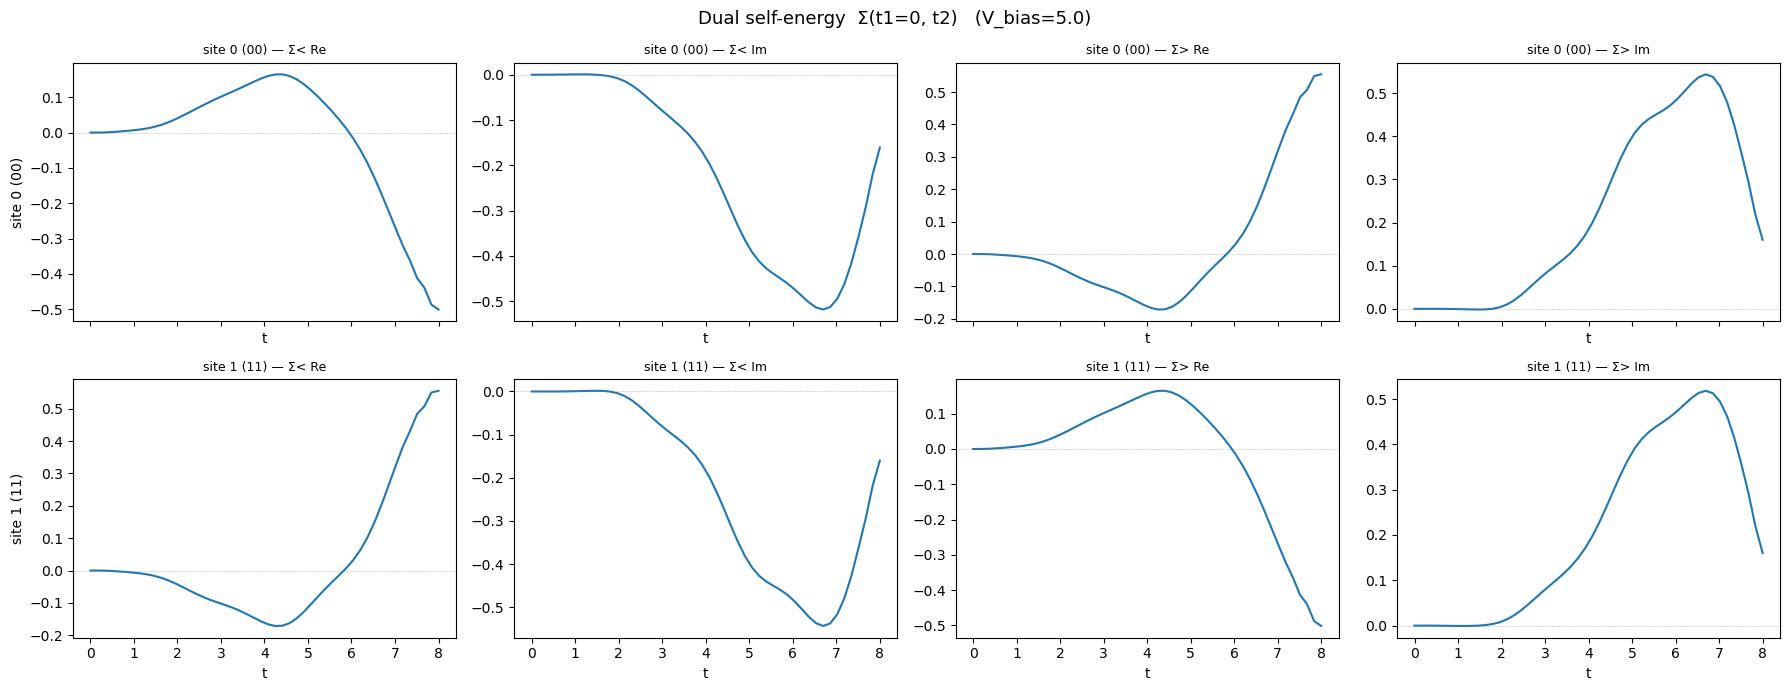

In [ ]:
# Plot 2: Dual self-energy Sigma(t1=0, t2)
# rows = sites (00, 11),  cols = (Sigma< Re | Sigma< Im | Sigma> Re | Sigma> Im)
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
fig.suptitle(f"Dual self-energy  Σ(t1=0, t2)   (V_bias={V_bias})", fontsize=13)

col_labels = ["Σ< Re", "Σ< Im", "Σ> Re", "Σ> Im"]

for row, (s, slabel) in enumerate(sites):
    sig_lt = Sigma_BF[0, :, s, s]
    sig_gt = Sigma_FB[0, :, s, s]

    data = [sig_lt.real, sig_lt.imag, sig_gt.real, sig_gt.imag]

    for col, (vals, clabel) in enumerate(zip(data, col_labels)):
        ax = axes[row, col]
        ax.plot(t_mesh, vals, lw=1.5)
        ax.axhline(0, color="gray", lw=0.4, ls=":")
        ax.set_title(f"{slabel} — {clabel}", fontsize=9)
        ax.set_xlabel("t")
        if col == 0:
            ax.set_ylabel(slabel)

plt.tight_layout()
plt.show()


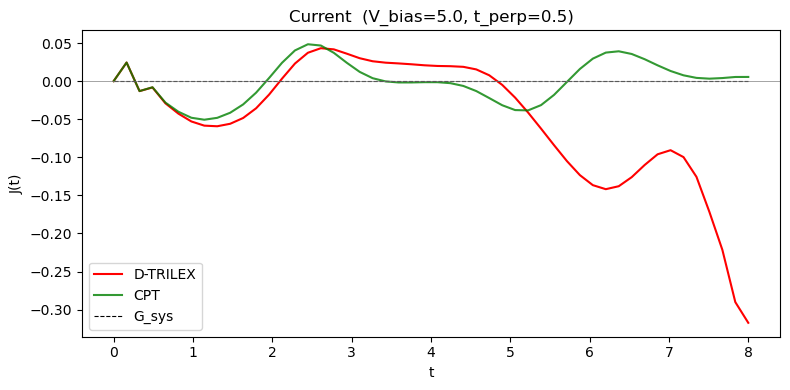

In [ ]:
# Plot 3: Current  J(t) = 4 t_perp * Re[ G^<_{10}(t,t) ]
# realevol convention: G^< = -i<c†c>, so <c†c> = i G^<
# J = 4 t_perp Im[<c†_0 c_1>] = 4 t_perp Im[i G^<_{10}] = 4 t_perp Re[G^<_{10}]
J_dtrilex = 4 * t_perp * np.real(np.diag(G_dtrilex_BF[..., 1, 0]))
J_cpt     = 4 * t_perp * np.real(np.diag(G_cpt_BF[..., 1, 0]))
J_sys     = 4 * t_perp * np.real(np.diag(G_sys_BF[..., 1, 0]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_mesh, J_dtrilex, "r-",  label="D-TRILEX")
ax.plot(t_mesh, J_cpt,     "g-",  label="CPT",     alpha=0.8)
ax.plot(t_mesh, J_sys,     "k--", label="G_sys",   lw=0.8)
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("t")
ax.set_ylabel("J(t)")
ax.set_title(f"Current  (V_bias={V_bias}, t_perp={t_perp})")
ax.legend()
plt.tight_layout()
plt.show()

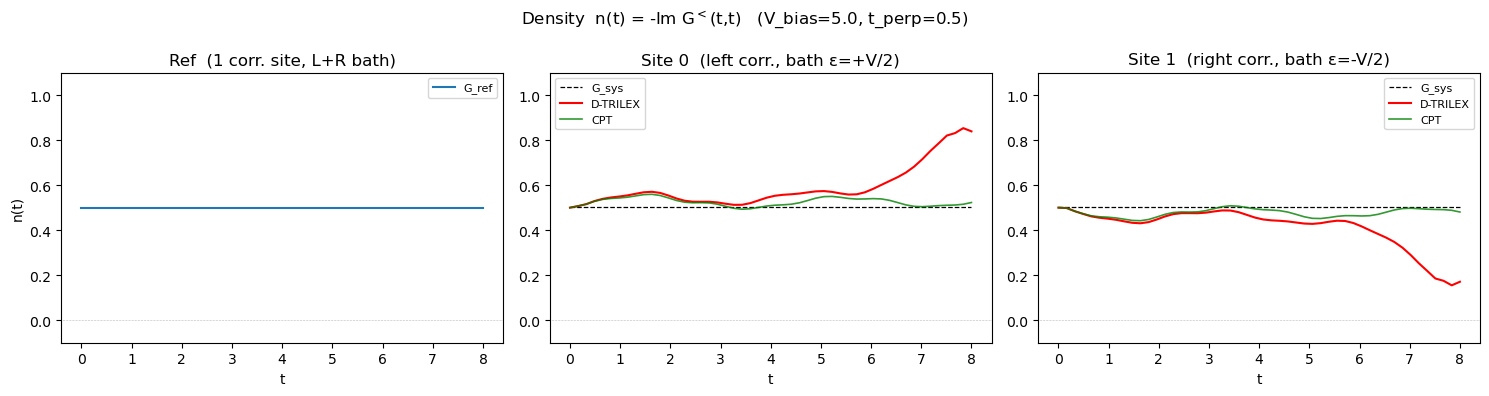

In [ ]:
# Plot 4: Density  n(t) = -Im[ G^<(t,t) ]
# realevol convention: G^<(t,t) = -i<n>, so n = -Im[G^<(t,t)]
n_ref    = -np.imag(np.diag(G_ref_BF))
n_sys_0  = -np.imag(np.diag(G_sys_BF[..., 0, 0]))
n_sys_1  = -np.imag(np.diag(G_sys_BF[..., 1, 1]))
n_dtri_0 = -np.imag(np.diag(G_dtrilex_BF[..., 0, 0]))
n_dtri_1 = -np.imag(np.diag(G_dtrilex_BF[..., 1, 1]))
n_cpt_0  = -np.imag(np.diag(G_cpt_BF[..., 0, 0]))
n_cpt_1  = -np.imag(np.diag(G_cpt_BF[..., 1, 1]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Density  n(t) = -Im G$^<$(t,t)   (V_bias={V_bias}, t_perp={t_perp})", fontsize=12)

axes[0].plot(t_mesh, n_ref, color="tab:blue", lw=1.5, label="G_ref")
axes[0].axhline(0, color="gray", lw=0.4, ls=":")
axes[0].set_ylim(-0.1, 1.1)
axes[0].set_title("Ref  (1 corr. site, L+R bath)")
axes[0].set_xlabel("t")
axes[0].set_ylabel("n(t)")
axes[0].legend(fontsize=8)

axes[1].plot(t_mesh, n_sys_0,  "k--", lw=0.9, label="G_sys")
axes[1].plot(t_mesh, n_dtri_0, "r-",  lw=1.5, label="D-TRILEX")
axes[1].plot(t_mesh, n_cpt_0,  "g-",  lw=1.2, label="CPT", alpha=0.8)
axes[1].axhline(0, color="gray", lw=0.4, ls=":")
axes[1].set_ylim(-0.1, 1.1)
axes[1].set_title("Site 0  (left corr., bath ε=+V/2)")
axes[1].set_xlabel("t")
axes[1].legend(fontsize=8)

axes[2].plot(t_mesh, n_sys_1,  "k--", lw=0.9, label="G_sys")
axes[2].plot(t_mesh, n_dtri_1, "r-",  lw=1.5, label="D-TRILEX")
axes[2].plot(t_mesh, n_cpt_1,  "g-",  lw=1.2, label="CPT", alpha=0.8)
axes[2].axhline(0, color="gray", lw=0.4, ls=":")
axes[2].set_ylim(-0.1, 1.1)
axes[2].set_title("Site 1  (right corr., bath ε=-V/2)")
axes[2].set_xlabel("t")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Current Experiment (biased junction)


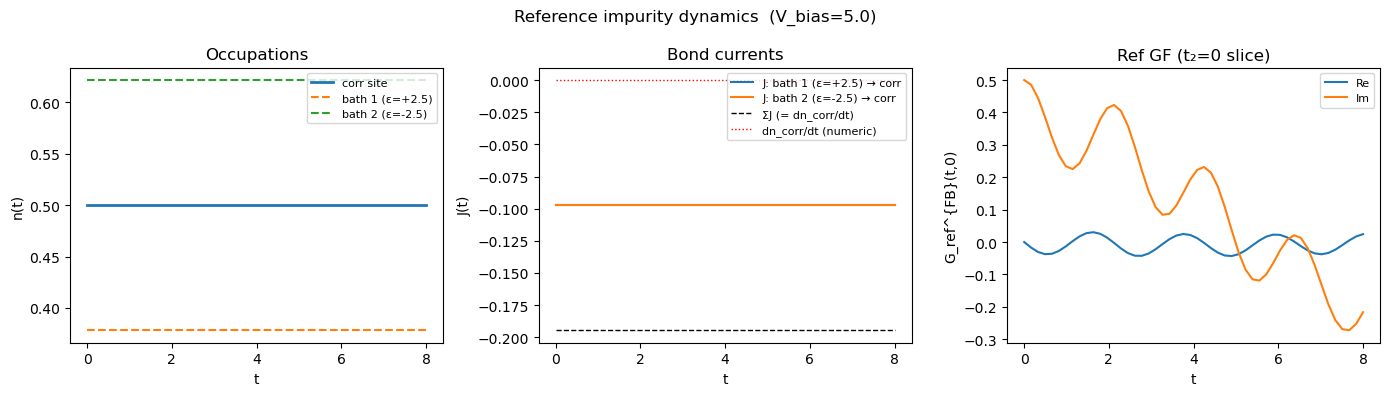

Saved current_dynamics.pdf


In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

CURRENT_H5 = "data/current/current_results.h5"

with h5py.File(CURRENT_H5, "r") as f:
    t       = f["t_mesh"][:]
    V_bias  = float(f["V_bias"][()])
    n_occ   = f["ref/n_occ"][:]        # (n_t, N): col 0=corr, 1..=bath sites
    J       = f["ref/J_to_imp"][:]     # (n_t, n_bath): current bath_j -> corr
    eps_b   = f["ref/eps_bath"][:]     # (n_bath,) bath energies

    # G^{FB}(t, t2=0) diagonal: track how the corr-site propagator evolves
    g_ref_fb = f["ref/G_ref/FB"][:]    # (n_t, n_t, 1, 1)
    g_ref_t0 = g_ref_fb[:, 0, 0, 0]    # (n_t,) fixed t2=0 slice

n_bath = J.shape[1]
bath_labels = [f"bath {i+1} (ε={eps_b[i]:+.1f})" for i in range(n_bath)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"Reference impurity dynamics  (V_bias={V_bias})", fontsize=12)

# --- Panel 1: occupations ---
ax = axes[0]
ax.plot(t, n_occ[:, 0], lw=2, label="corr site")
for i in range(n_bath):
    ax.plot(t, n_occ[:, i + 1], lw=1.5, ls="--", label=bath_labels[i])
ax.set(xlabel="t", ylabel="n(t)", title="Occupations")
ax.legend(fontsize=8)

# --- Panel 2: bond currents ---
ax = axes[1]
for i in range(n_bath):
    ax.plot(t, J[:, i], lw=1.5, label=f"J: {bath_labels[i]} → corr")
J_total = J.sum(axis=1)
ax.plot(t, J_total, "k--", lw=1, label="ΣJ (= dn_corr/dt)")
# overlay numerical derivative as sanity check
dn_dt = np.gradient(n_occ[:, 0], t)
ax.plot(t, dn_dt, "r:", lw=1, label="dn_corr/dt (numeric)")
ax.set(xlabel="t", ylabel="J(t)", title="Bond currents")
ax.legend(fontsize=8)

# --- Panel 3: G_ref^{FB}(t, 0) ---
ax = axes[2]
ax.plot(t, np.real(g_ref_t0), label="Re")
ax.plot(t, np.imag(g_ref_t0), label="Im")
ax.set(xlabel="t", ylabel="G_ref^{FB}(t,0)", title="Ref GF (t₂=0 slice)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(plots_dir / "current_dynamics.pdf", bbox_inches="tight")
plt.show()
print("Saved current_dynamics.pdf")
